In [89]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from warnings import filterwarnings
filterwarnings('ignore')

<h3> Data Loading

In [90]:
category = pd.read_csv('category_translation.csv')
customers = pd.read_csv('customers.csv')
location = pd.read_csv('location.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_item.csv')
payments = pd.read_csv('payments.csv')
products = pd.read_csv('products.csv')
reviews = pd.read_csv('reviews.csv')
sellers = pd.read_csv('sellers.csv')

<h3> Initial Exploration, Data Cleaning and Preprocessing

In [91]:
# creating a function to explore the data
def init_explore(df):
    print("Shape of the dataset:", df.shape)
    print("\nData types:\n", df.dtypes)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nUnique values:\n", df.nunique())
    print("\nFirst 5 rows:\n", df.head())
    print("\nDuplicates:\n", df.duplicated().sum())

<h5> 1. Category

In [92]:
init_explore(category)

Shape of the dataset: (71, 2)

Data types:
 product_category_name            object
product_category_name_english    object
dtype: object

Missing values:
 product_category_name            0
product_category_name_english    0
dtype: int64

Unique values:
 product_category_name            71
product_category_name_english    71
dtype: int64

First 5 rows:
     product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor

Duplicates:
 0


<h5>2. Customers

In [93]:
init_explore(customers)

Shape of the dataset: (99441, 5)

Data types:
 customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Missing values:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Unique values:
 customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

First 5 rows:
                         customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4 

In [94]:
#understanding the number of unique customers and their frequency of orders
customers.groupby('customer_unique_id').agg({'customer_id': 'nunique'}).reset_index().sort_values(by='customer_id', ascending=False)

,customer_unique_id,customer_id
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
...,...,...
32508,5657dfebff5868c4dc7e8355fea865c4,1
32507,5657596addb4d7b07b32cd330614bdf8,1
32506,5656eb169546146caeab56c3ffc3d268,1
32505,5656a8fabc8629ff96b2bc14f8c09a27,1


In [95]:
# capitalize city names
customers['customer_city'] =  customers['customer_city'].str.capitalize()

<h5> Location

- has duplicates

In [96]:
init_explore(location)

Shape of the dataset: (1000163, 5)

Data types:
 geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

Missing values:
 geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Unique values:
 geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64

First 5 rows:
    geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   
3                         1041       -

In [97]:
#checking for duplicate locations
location[location.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [98]:
#dropping duplicates
location.drop_duplicates(inplace=True)

In [99]:
#capitalize city names
location['geolocation_city'] = location['geolocation_city'].str.capitalize()

<h5> Order Items

- shipping limit_date needs to be converted to datetime
- the order_item_id column is creating duplicates in the table. The column should be dropped and the dataframe should be aggregated to as product_qty.

In [100]:
init_explore(order_items)

Shape of the dataset: (112650, 7)

Data types:
 order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Missing values:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Unique values:
 order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

First 5 rows:
                            order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1

In [101]:
# checking if combinatiton of order_id and product_id and seller_id is unique in order_items
order_items.groupby(['order_id', 'product_id','seller_id']).size().reset_index(name='count').sort_values(by='count', ascending=False)

,order_id,product_id,seller_id,count
10850,1b15974a0141d54e36626dca3fdc731a,ee3d532c8a438679776d222e997606b3,8e6d7754bc7e0f22c96d255ebda59eba,20
68186,ab14fdcfbe524636d65ee38360e22ce8,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,20
26550,428a2f660dc84138d969ccd69a0ab6d5,89b190a046022486c635022524a974a8,f326006815956455b2859abd58fe7e39,15
63242,9ef13efd6949e4573a18964dd1bbe7f5,37eb69aca8718e843d897aa7b82f462d,0b36063d5818f81ccb94b54adfaebbf5,15
46268,73c8ab38f07dc94389065f7eba4f297a,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,14
...,...,...,...,...
35388,5897449bce69856d88610b3c0f4f63b5,b0364648b1c062169015d9234d97d306,4da0e408c99d2fdc2126dc9fce518060,1
35387,5896d753079d9faa8aeaf60231b3e788,cce679660c66e6fbd5c8091dfd29e9cd,d2374cbcbb3ca4ab1086534108cc3ab7,1
35386,589673b4d98b5c40931ac6a6ff6f3416,fe01b643060a6446e59f58e3021e66b3,2dee2ce60de9709b1a24083217181a1f,1
35385,5895d82d31799f8d7ad6748c25e76dad,24c66f106f642621e524291a895c9032,620c87c171fb2a6dd6e8bb4dec959fc6,1


In [102]:
order_items.groupby(['order_id']).agg({'product_id': 'nunique'}).reset_index().sort_values(by='product_id', ascending=False)

,order_id,product_id
77909,ca3625898fbd48669d50701aba51cd5f,8
48309,7d8f5bfd5aff648220374a2df62e84d5,7
46116,77df84f9195be22a4e9cb72ca9e8b4c2,7
66653,ad850e69fce9a512ada84086651a2e7d,7
36443,5efc0b7fe9df7f0c567404abaa4d25fc,6
...,...,...
33440,56d0a27ec26d1644336aff1ec939c089,1
33439,56d01e37808556640e75a40c8202b0a8,1
33438,56ce64b53ec3bb5b0525f21506619f8e,1
33437,56ce3873eb6d633a47581ec221f50a65,1


In [103]:
order_items[order_items['order_id'] == 'ca3625898fbd48669d50701aba51cd5f']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
89007,ca3625898fbd48669d50701aba51cd5f,1,1065e0ebef073787a7bf691924c60eeb,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,309.0,1.84
89008,ca3625898fbd48669d50701aba51cd5f,2,0cf2faf9749f53924cea652a09d8e327,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,33.9,1.84
89009,ca3625898fbd48669d50701aba51cd5f,3,0de59eddc63167215c972b0d785ffa7b,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,159.0,3.67
89010,ca3625898fbd48669d50701aba51cd5f,4,0de59eddc63167215c972b0d785ffa7b,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,159.0,3.67
89011,ca3625898fbd48669d50701aba51cd5f,5,5dae498eff2d80057f56122235a36aff,888faa8bfb0b159c37de6d898b961c31,2018-08-17 02:25:07,95.9,0.15
89012,ca3625898fbd48669d50701aba51cd5f,6,4a5c3967bfd3629fe07ef4d0cc8c3818,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,109.9,0.15
89013,ca3625898fbd48669d50701aba51cd5f,7,678c229b41c0e497d35a25a8be1cc631,888faa8bfb0b159c37de6d898b961c31,2018-08-17 02:25:07,95.9,0.15
89014,ca3625898fbd48669d50701aba51cd5f,8,21b524c4c060169fa75ccf08c7da4627,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,63.7,0.15
89015,ca3625898fbd48669d50701aba51cd5f,9,309dd69eb83cea38c51709d62befe1a4,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,56.0,3.68
89016,ca3625898fbd48669d50701aba51cd5f,10,309dd69eb83cea38c51709d62befe1a4,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,56.0,3.68


In [104]:
#summarizing the total quantity of each product sold by each seller for each order
order_items_grouped = order_items.groupby(['order_id', 
                                           'product_id', 
                                           'seller_id', 
                                           'shipping_limit_date', 
                                           'price', 
                                           'freight_value']).agg({'order_item_id': 'count'}).reset_index().rename(columns={'order_item_id': 'total_qty'})

In [105]:
order_items_grouped[order_items_grouped['order_id'] == 'ca3625898fbd48669d50701aba51cd5f']

,order_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_qty
80867,ca3625898fbd48669d50701aba51cd5f,0cf2faf9749f53924cea652a09d8e327,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,33.9,1.84,1
80868,ca3625898fbd48669d50701aba51cd5f,0de59eddc63167215c972b0d785ffa7b,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,159.0,3.67,2
80869,ca3625898fbd48669d50701aba51cd5f,1065e0ebef073787a7bf691924c60eeb,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,309.0,1.84,1
80870,ca3625898fbd48669d50701aba51cd5f,21b524c4c060169fa75ccf08c7da4627,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,63.7,0.15,1
80871,ca3625898fbd48669d50701aba51cd5f,309dd69eb83cea38c51709d62befe1a4,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,56.0,3.68,2
80872,ca3625898fbd48669d50701aba51cd5f,4a5c3967bfd3629fe07ef4d0cc8c3818,0b35c634521043bf4b47e21547b99ab5,2018-08-16 02:25:07,109.9,0.15,1
80873,ca3625898fbd48669d50701aba51cd5f,5dae498eff2d80057f56122235a36aff,888faa8bfb0b159c37de6d898b961c31,2018-08-17 02:25:07,95.9,0.15,1
80874,ca3625898fbd48669d50701aba51cd5f,678c229b41c0e497d35a25a8be1cc631,888faa8bfb0b159c37de6d898b961c31,2018-08-17 02:25:07,95.9,0.15,1


In [106]:
order_items_grouped.sort_values(by='total_qty', ascending=False)

,order_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_qty
10850,1b15974a0141d54e36626dca3fdc731a,ee3d532c8a438679776d222e997606b3,8e6d7754bc7e0f22c96d255ebda59eba,2018-03-01 02:50:48,100.00,10.12,20
68186,ab14fdcfbe524636d65ee38360e22ce8,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.70,14.44,20
26550,428a2f660dc84138d969ccd69a0ab6d5,89b190a046022486c635022524a974a8,f326006815956455b2859abd58fe7e39,2017-11-30 10:30:51,65.49,16.22,15
63242,9ef13efd6949e4573a18964dd1bbe7f5,37eb69aca8718e843d897aa7b82f462d,0b36063d5818f81ccb94b54adfaebbf5,2017-02-03 21:44:49,51.00,1.20,15
46268,73c8ab38f07dc94389065f7eba4f297a,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2017-12-21 02:30:41,59.00,13.43,14
...,...,...,...,...,...,...,...
35388,5897449bce69856d88610b3c0f4f63b5,b0364648b1c062169015d9234d97d306,4da0e408c99d2fdc2126dc9fce518060,2017-01-19 21:46:43,183.90,15.46,1
35387,5896d753079d9faa8aeaf60231b3e788,cce679660c66e6fbd5c8091dfd29e9cd,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-02 09:45:36,17.90,15.10,1
35386,589673b4d98b5c40931ac6a6ff6f3416,fe01b643060a6446e59f58e3021e66b3,2dee2ce60de9709b1a24083217181a1f,2018-06-19 16:32:32,169.00,57.95,1
35385,5895d82d31799f8d7ad6748c25e76dad,24c66f106f642621e524291a895c9032,620c87c171fb2a6dd6e8bb4dec959fc6,2018-06-12 00:55:28,199.90,16.10,1


<h5> Orders

In [107]:
init_explore(orders)

Shape of the dataset: (99441, 8)

Data types:
 order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing values:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Unique values:
 order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    

<Axes: >

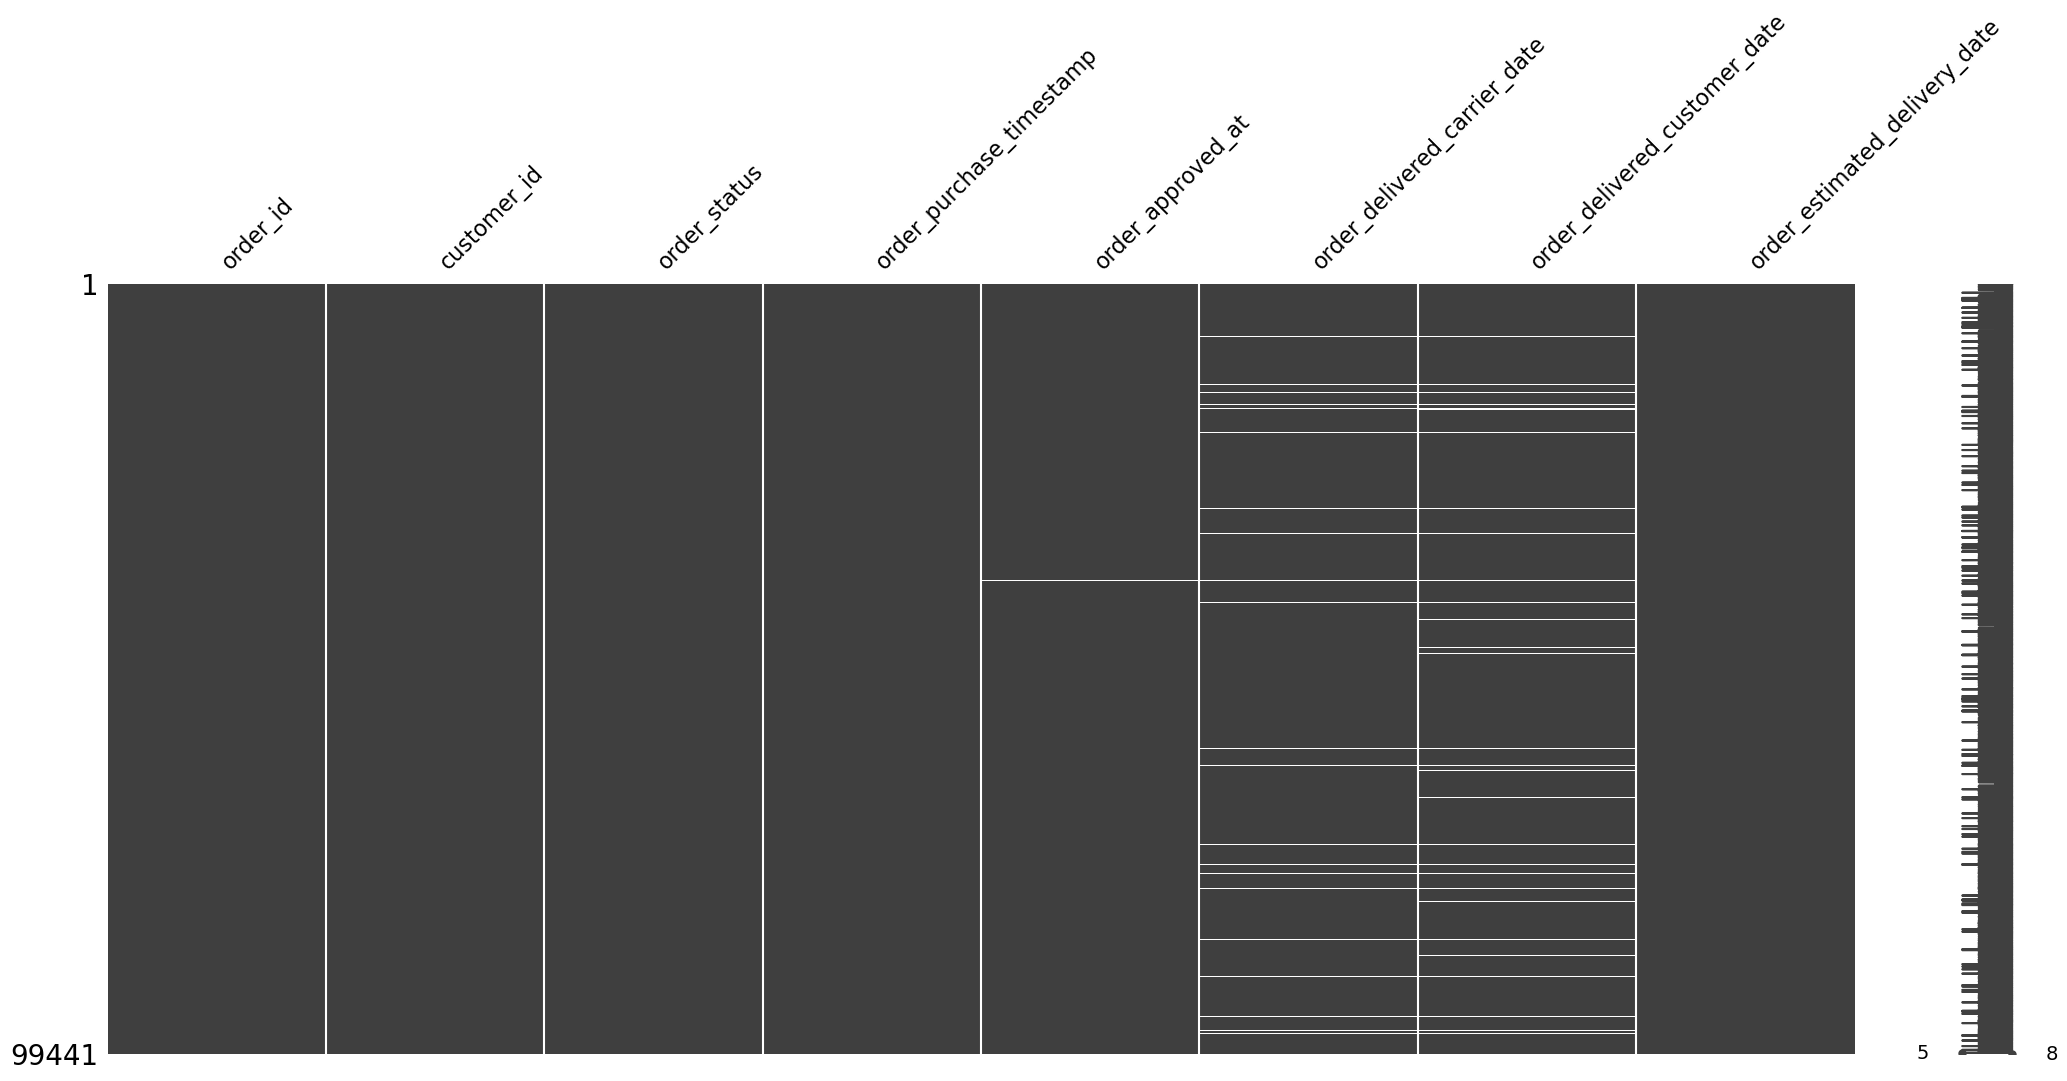

In [108]:
#understanding missing values in orders
msno.matrix(orders)

The matrix shows significant correlation in missing values in delivery times to carrier and customer. This can be an expected behaviour, when the order has not been delivered to the carrier for shipment and the order has also not been delivered to customer.

By Business Logic:
- case 1: when order is delivered it should have all the three approved, carrier_delivery and customer_delivery_date
- case 2: when order is shipped it should have approved and carrier_delivery date
- case 3: when order is approved it should have approved date

In [109]:
# checking for unique status values in orders
orders['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [110]:
orders[(orders['order_status'].isin(['approved', 'shipped', 'delivered'])) & orders['order_approved_at'].isna()] 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00


In [111]:
orders[(orders['order_status'].isin(['shipped', 'delivered'])) & orders['order_delivered_carrier_date'].isna()] 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


In [112]:
orders[(orders['order_status'].isin(['delivered'])) & orders['order_delivered_customer_date'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


Since all the missing values are from status = delivered, we can use some simple techniques to calculate the impute the missing values:

case 1: approved_at = purchase_tmsp + avg/p90 of time taken from purchase to approval for delivered orders

case 2: carrier_date = approved_tmsp + avg/p90 of time taken from approval to shipping for delivered orders

case 3: delivered_at = carrier_delivery_tmsp + avg/p90 of time taken from carrier to customer for delivered orders

In [113]:
#converting date columns to datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [114]:
orders['purchase_to_approval_time'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600
orders['approval_to_carrier_time'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.total_seconds() / 3600
orders['carrier_to_customer_time'] = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.total_seconds() / 3600

In [115]:
#calculating 90th percentile for purchase_to_approval_time, approval_to_carrier_time, and carrier_to_customer_time for delivered orders
p90_approved_at = orders[orders['order_status'].isin(['delivered'])]['purchase_to_approval_time'].quantile(0.9)
p90_carrier_date = orders[orders['order_status'].isin(['delivered'])]['approval_to_carrier_time'].quantile(0.9)
p90_delivered_date = orders[orders['order_status'].isin(['delivered'])]['carrier_to_customer_time'].quantile(0.9)

In [116]:
#imputing missing values in orders based on order_status and calculated 90th percentiles
orders.loc[(orders['order_status'].isin(['approved', 'shipped', 'delivered'])) & orders['order_approved_at'].isna(), 'order_approved_at'] = orders['order_purchase_timestamp'] + pd.to_timedelta(p90_approved_at, unit='h')
orders.loc[(orders['order_status'].isin(['shipped', 'delivered'])) & orders['order_delivered_carrier_date'].isna(), 'order_delivered_carrier_date'] = orders['order_approved_at'] + pd.to_timedelta(p90_carrier_date, unit='h')
orders.loc[(orders['order_status'].isin(['delivered'])) & orders['order_delivered_customer_date'].isna(), 'order_delivered_customer_date'] = orders['order_delivered_carrier_date'] + pd.to_timedelta(p90_delivered_date, unit='h') 

<h5> Payments

In [117]:
init_explore(payments)

Shape of the dataset: (103886, 5)

Data types:
 order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

Missing values:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Unique values:
 order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

First 5 rows:
                            order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  cred

In [118]:
payments.groupby('order_id').agg({'payment_sequential': 'nunique'}).reset_index().sort_values(by='payment_sequential', ascending=False)

,order_id,payment_sequential
97261,fa65dad1b0e818e3ccc5cb0e39231352,29
79611,ccf804e764ed5650cd8759557269dc13,26
15577,285c2e15bebd4ac83635ccc563dc71f4,22
53168,895ab968e7bb0d5659d16cd74cd1650c,21
99020,fedcd9f7ccdc8cba3a18defedd1a5547,19
...,...,...
33697,56bd45163229b35ca0ab490c1e3d3233,1
33696,56bc98e6d5b88c2cdb905f2fbec2ca3a,1
33695,56bbc7d92e6e74b8782abbf5ee336a92,1
33694,56bafc014f8ed2f34cfe598592c65fd8,1


In [119]:
payments[payments['order_id'] == 'fa65dad1b0e818e3ccc5cb0e39231352']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
4885,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02
9985,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16
14321,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71
17274,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08
19565,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86
23074,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51
24879,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68
28330,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66
29648,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02
32519,fa65dad1b0e818e3ccc5cb0e39231352,11,voucher,1,4.03


In [120]:
payments_grouped = payments.groupby(['order_id', 'payment_type', 'payment_installments']).agg({'payment_sequential': 'count', 'payment_value': 'sum'}).reset_index().rename(columns={'payment_sequential': 'payment_qty', 'payments_value': 'total_payments'})

In [121]:
payments_grouped.sort_values(by='payment_qty', ascending=False)

,order_id,payment_type,payment_installments,payment_qty,payment_value
99600,fa65dad1b0e818e3ccc5cb0e39231352,voucher,1,29,457.99
81519,ccf804e764ed5650cd8759557269dc13,voucher,1,25,60.48
54474,895ab968e7bb0d5659d16cd74cd1650c,voucher,1,21,161.32
15979,285c2e15bebd4ac83635ccc563dc71f4,voucher,1,21,39.23
94953,ee9ca989fc93ba09a6eddc250ce01742,voucher,1,18,80.97
...,...,...,...,...,...
34131,55b0d8973155b2b01e1849cd54bb8d89,boleto,1,1,47.29
34130,55af89bd3634844abc96b00c4caa76a5,credit_card,4,1,128.87
34129,55af3f02d418fbfae46c0e04bffe4676,boleto,1,1,111.19
34128,55aeba08a7d54fd54220244c4dfdb559,credit_card,1,1,56.69


In [122]:
payments_grouped[payments_grouped['order_id'].duplicated()].sort_values(by='payment_qty', ascending=False)

,order_id,payment_type,payment_installments,payment_qty,payment_value
81519,ccf804e764ed5650cd8759557269dc13,voucher,1,25,60.48
15979,285c2e15bebd4ac83635ccc563dc71f4,voucher,1,21,39.23
94953,ee9ca989fc93ba09a6eddc250ce01742,voucher,1,18,80.97
101407,fedcd9f7ccdc8cba3a18defedd1a5547,voucher,1,18,204.07
30316,4bfcba9e084f46c8e3cb49b0fa6e6159,voucher,1,14,700.00
...,...,...,...,...,...
35046,580e21d2e46243eca1eb813c5fe6ac7a,voucher,1,1,22.36
35010,57eede1060c3e289d5be82560b4874b7,voucher,1,1,50.00
34963,57d86c396c1d48482e96e9e4a0e14ffb,voucher,1,1,18.67
34942,57cc72d3e635bf57199d76328279b875,voucher,1,1,40.63


In [123]:
payments_grouped[payments_grouped['order_id'] == 'ccf804e764ed5650cd8759557269dc13']

,order_id,payment_type,payment_installments,payment_qty,payment_value
81518,ccf804e764ed5650cd8759557269dc13,credit_card,1,1,2.20
81519,ccf804e764ed5650cd8759557269dc13,voucher,1,25,60.48


<h5> Product

- some column names needs changing
- some columns have null values

In [124]:
init_explore(products)

Shape of the dataset: (32951, 9)

Data types:
 product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Missing values:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Unique values:
 product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm          

In [125]:
#replacing null values in product_category_name with 'unknown'
products['product_category_name'].fillna('unknown', inplace=True)

<h5> Reviews

- lot of null values in title and message column
- some columns need renaming

In [126]:
init_explore(reviews)

Shape of the dataset: (99224, 7)

Data types:
 review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

Missing values:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Unique values:
 review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64

First 5 rows:
                           review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f

In [127]:
reviews[reviews['review_id'] == '832acec9bbf4efe65c3fb6423d8b4ed7']

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
32233,832acec9bbf4efe65c3fb6423d8b4ed7,66f943fd426ac8716ef6b6b97ace8bd8,4,NaN,NaN,2018-05-10 00:00:00,2018-05-11 10:53:21
38993,832acec9bbf4efe65c3fb6423d8b4ed7,b9a528ec4ad891d009b3dc50588218f1,4,NaN,NaN,2018-05-10 00:00:00,2018-05-11 10:53:21
55964,832acec9bbf4efe65c3fb6423d8b4ed7,cf954e7391c1981cc9090267aec67ee9,4,NaN,NaN,2018-05-10 00:00:00,2018-05-11 10:53:21


In [128]:
#review_comment_title and review_comment_message have too any null values, so we can drop them
reviews.drop(columns=['review_comment_title', 'review_comment_message'], inplace=True)

In [129]:
reviews.duplicated().sum()

0

In [130]:
reviews.groupby('review_id').agg({'order_id': 'nunique'}).reset_index().sort_values(by='order_id', ascending=False)

,review_id,order_id
85346,ddc52555ca27b0fe67d5255147682d2d,3
17423,2d6ac45f859465b5c185274a1c929637,3
40583,69a1068c3128a14994e3e422e4539e04,3
12172,1fb4ddc969e6bea80e38deec00393a6f,3
50493,832acec9bbf4efe65c3fb6423d8b4ed7,3
...,...,...
32923,55e786108c25c7189556f979d36d21e2,1
32922,55e75349772296ce03638d94f56a2551,1
32921,55e7223cc9cf2266d2b5c94587727239,1
32920,55e718e1ad1ab74f486f8f1339029ad1,1


In [131]:
reviews.groupby('order_id').agg({'review_id': 'nunique'}).reset_index().sort_values(by='review_id', ascending=False)

,order_id,review_id
54489,8e17072ec97ce29f0e1f111e598b0c85,3
77319,c88b1d1b157a9999ce368f218a407141,3
1455,03c939fd7fd3b38f8485a0f95798f1f6,3
86232,df56136b8031ecd28e200bb18e6ddb2e,3
15722,29062384ce4975f78aeba6a496510386,2
...,...,...
32987,559609410c90dc1792181a5f260a6600,1
32986,5595480d373b37e5738fc085dd9bcb8e,1
32985,559115c14f48d999adcc027b4a702c8b,1
32984,5590b14b260d2f61b2db5efb8d4a4601,1


In [132]:
reviews[reviews['order_id'] == 'c88b1d1b157a9999ce368f218a407141']

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
1985,ffb8cff872a625632ac983eb1f88843c,c88b1d1b157a9999ce368f218a407141,3,2017-07-22 00:00:00,2017-07-26 13:41:07
82525,202b5f44d09cd3cfc0d6bd12f01b044c,c88b1d1b157a9999ce368f218a407141,5,2017-07-22 00:00:00,2017-07-26 13:40:22
89360,fb96ea2ef8cce1c888f4d45c8e22b793,c88b1d1b157a9999ce368f218a407141,5,2017-07-21 00:00:00,2017-07-26 13:45:15


<h5> Sellers

In [133]:
init_explore(sellers)

Shape of the dataset: (3095, 4)

Data types:
 seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

Missing values:
 seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Unique values:
 seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64

First 5 rows:
                           seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     ri

In [134]:
sellers['seller_city'] = sellers['seller_city'].str.capitalize()

In [135]:
# changing dtype for zip code columns to string and padding with leading zeros to ensure consistent formatting
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str).str.zfill(8)
location['geolocation_zip_code_prefix'] = location['geolocation_zip_code_prefix'].astype(str).str.zfill(8)
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str).str.zfill(8)

In [136]:
# Renaming columns for better readability
category.rename(columns={'product_category_name': 'category_name', 
                         'product_category_name_english': 'category_name_english'}, inplace=True)
# customers.rename(columns={'customer_zip_code_prefix': 'zip_code_prefix', 
#                           'customer_city': 'city', 
#                           'customer_state': 'state'}, inplace=True)
location.rename(columns={'geolocation_zip_code_prefix': 'zip_code_prefix',
                         'geolocation_lat': 'latitude',
                         'geolocation_lng': 'longitude',
                         'geolocation_city': 'city',
                         'geolocation_state': 'state'}, inplace=True)
orders.rename(columns={'order_purchase_timestamp': 'purchase_tmsp',
                       'order_approved_at': 'approved_tmsp',
                       'order_delivered_carrier_date': 'delivered_carrier_tmsp',
                       'order_delivered_customer_date': 'delivered_customer_tmsp',
                       'order_estimated_delivery_date': 'estimated_delivery_tmsp'}, inplace=True)
products.rename(columns={'product_category_name': 'category_name',
                         'product_name_lenght': 'name_length',
                         'product_description_lenght': 'description_length',
                         'product_photos_qty': 'photos_qty',
                         'product_weight_g': 'weight_g',
                         'product_length_cm': 'length_cm',  
                         'product_height_cm': 'height_cm',
                         'product_width_cm': 'width_cm'}, inplace=True)
reviews.rename(columns={'review_comment_title': 'review_title',
                        'review_comment_message': 'review_message',
                        'review_creation_date': 'review_creation_tmsp',
                        'review_answer_timestamp': 'review_answer_tmsp'}, inplace=True)
# sellers.rename(columns={'seller_zip_code_prefix': 'zip_code_prefix',
#                         'seller_city': 'city',  
#                         'seller_state': 'state'}, inplace=True)



<h2> Combining Datasets

In [137]:
combined = orders.merge(customers, on='customer_id', how='left')\
.merge(order_items_grouped, on='order_id', how='left')\
.merge(products, on='product_id', how='left')\
.merge(payments, on='order_id', how='left')\
.merge(reviews, on='order_id', how='left')\
.merge(sellers, on='seller_id', how='left')\
.merge(category, on='category_name', how='left')



In [138]:
combined.head()

,order_id,customer_id,order_status,purchase_tmsp,approved_tmsp,delivered_carrier_tmsp,delivered_customer_tmsp,estimated_delivery_tmsp,purchase_to_approval_time,approval_to_carrier_time,...,payment_installments,payment_value,review_id,review_score,review_creation_tmsp,review_answer_tmsp,seller_zip_code_prefix,seller_city,seller_state,category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,56.795833,...,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,2017-10-12 03:43:48,00009350,Maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,56.795833,...,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,2017-10-12 03:43:48,00009350,Maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,56.795833,...,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,2017-10-12 03:43:48,00009350,Maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,11.109167,...,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08 00:00:00,2018-08-08 18:37:50,00031570,Belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,4.910278,...,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18 00:00:00,2018-08-22 19:07:58,00014840,Guariba,SP,auto


In [139]:
combined.duplicated().sum()

0

In [140]:
combined.shape

(108502, 41)

In [141]:
combined.columns

Index(['order_id', 'customer_id', 'order_status', 'purchase_tmsp',
       'approved_tmsp', 'delivered_carrier_tmsp', 'delivered_customer_tmsp',
       'estimated_delivery_tmsp', 'purchase_to_approval_time',
       'approval_to_carrier_time', 'carrier_to_customer_time',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'total_qty', 'category_name', 'name_length',
       'description_length', 'photos_qty', 'weight_g', 'length_cm',
       'height_cm', 'width_cm', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_creation_tmsp', 'review_answer_tmsp', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'category_name_english'],
      dtype='object')

In [142]:
combined.rename(columns={'zip_code_prefix_x' : 'customers_zip_code_prefix', 'zip_code_prefix_y' : 'sellers_zip_code_prefix', 'city_x': 'customers_city', 'city_y': 'sellers_city', 'state_x': 'customers_state', 'state_y': 'sellers_state'}, inplace=True)

In [143]:
combined['time_taken_to_deliver'] = (combined['delivered_customer_tmsp'] - combined['purchase_tmsp']).dt.total_seconds() / (3600*24)
combined['year_of_purchase'] = combined['purchase_tmsp'].dt.year
combined['month_of_purchase'] = combined['purchase_tmsp'].dt.month
combined['year_of_delivery'] = combined['delivered_customer_tmsp'].dt.year
combined['month_of_delivery'] = combined['delivered_customer_tmsp'].dt.month
combined['on_time_delivery'] = combined['delivered_customer_tmsp'] <= combined['estimated_delivery_tmsp']

Customer Analytics

In [144]:
customer_facts = combined.groupby('customer_unique_id').agg({'order_id': 'nunique', 
                                                    'customer_zip_code_prefix' : 'first',
                                                    'payment_value': 'sum', 
                                                    'review_score': 'mean',
                                                    'customer_city': 'first',
                                                    'customer_state': 'first',
                                                    'purchase_tmsp': 'max'}).reset_index()\
                                                    .rename(columns={'order_id': 'total_orders',
                                                                     'customer_zip_code_prefix' : 'zip_code_prefix',
                                                                     'payment_value': 'total_spent', 
                                                                     'review_score': 'avg_review_score',
                                                                     'customer_city': 'city',
                                                                     'customer_state': 'state',
                                                                     'purchase_tmsp': 'last_purchase_date'})

In [145]:
customer_facts['last_purchase_date'].max()

Timestamp('2018-10-17 17:30:18')

In [146]:
customer_facts['avg_order_value'] = customer_facts['total_spent'] / customer_facts['total_orders']
# using the current date because the dataset is from 2018 and we want to calculate the number of days since the last purchase for each customer
customer_facts['day_since_last_purchase'] = (pd.to_datetime('2018-10-17 17:30:18') - customer_facts['last_purchase_date']).dt.days
customer_facts['ltv'] = customer_facts['avg_order_value'] * customer_facts['total_orders']
customer_facts['churned'] = customer_facts['day_since_last_purchase'] > 90

In [147]:
customer_facts.head()

,customer_unique_id,total_orders,zip_code_prefix,total_spent,avg_review_score,city,state,last_purchase_date,avg_order_value,day_since_last_purchase,ltv,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,1,00007787,141.90,5.0,Cajamar,SP,2018-05-10 10:56:27,141.90,160,141.90,True
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,00006053,27.19,4.0,Osasco,SP,2018-05-07 11:11:27,27.19,163,27.19,True
2,0000f46a3911fa3c0805444483337064,1,00088115,86.22,3.0,Sao jose,SC,2017-03-10 21:05:03,86.22,585,86.22,True
3,0000f6ccb0745a6a4b88665a16c9f078,1,00066812,43.62,4.0,Belem,PA,2017-10-12 20:29:41,43.62,369,43.62,True
4,0004aac84e0df4da2b147fca70cf8255,1,00018040,196.89,5.0,Sorocaba,SP,2017-11-14 19:45:42,196.89,336,196.89,True


Revenue Analysis

In [148]:
revenue = combined.groupby(['year_of_purchase','month_of_purchase'])\
    .agg({'order_id': 'nunique', 'payment_value': 'sum', 'customer_unique_id': 'nunique'}).reset_index()\
    .rename(columns={'order_id': 'total_orders', 'payment_value': 'total_revenue', 'customer_unique_id': 'total_customers'})

In [149]:
revenue.tail()

,year_of_purchase,month_of_purchase,total_orders,total_revenue,total_customers
20,2018,6,6167,1085878.94,6128
21,2018,7,6292,1126683.48,6230
22,2018,8,6512,1106742.72,6460
23,2018,9,16,4439.54,14
24,2018,10,4,589.67,4


In [150]:
revenue['month_year'] =  revenue['year_of_purchase'].astype(str) + '-' + revenue['month_of_purchase'].astype(str).str.zfill(2)
revenue_trend = revenue.groupby(['month_year']).agg({'total_revenue': 'sum'})

Product Analysis

In [151]:
product_facts = combined.groupby('product_id').agg({'order_id': 'nunique',
                                                   'payment_value': 'sum',
                                                    'review_score': 'mean',
                                                    'category_name_english': 'first'}).reset_index()\
                                                    .rename(columns={'order_id': 'total_orders',
                                                                        'payment_value': 'total_revenue',
                                                                        'review_score': 'avg_review_score',
                                                                        'category_name_english': 'category_name'})

In [152]:
product_facts.head()

,product_id,total_orders,total_revenue,avg_review_score,category_name
0,00066f42aeeb9f3007548bb9d3f33c38,1,120.24,5.0,perfumery
1,00088930e925c41fd95ebfe695fd2655,1,143.83,4.0,auto
2,0009406fd7479715e4bef61dd91f2462,1,242.10,1.0,bed_bath_table
3,000b8f95fcb9e0096488278317764d19,2,157.00,5.0,housewares
4,000d9be29b5207b54e86aa1b1ac54872,1,218.27,5.0,watches_gifts


Payment Methods Analysis

In [153]:
payment_facts = combined.groupby('payment_type').agg({'order_id': 'nunique', 'payment_value': 'sum', 'payment_installments': 'mean', 'customer_unique_id' : 'nunique'}).reset_index()\
    .rename(columns={'order_id': 'total_orders', 'payment_value': 'total_revenue', 'payment_installments': 'avg_installments', 'customer_unique_id': 'total_customers'})

In [154]:
payment_facts = payment_facts[payment_facts['payment_type'] != 'not_defined']

In [155]:
payment_facts['payment_type'] = payment_facts['payment_type'].str.replace('_', ' ').str.title()

Seller Analysis

In [156]:
seller_facts = combined.groupby('seller_id').agg({'order_id': 'nunique', 
                                                  'payment_value': 'sum', 
                                                  'review_score': 'mean', 
                                                  'seller_city': 'first', 
                                                  'seller_state': 'first', 
                                                  'seller_zip_code_prefix': 'first',
                                                  'time_taken_to_deliver': 'mean'})\
                                                .reset_index()\
                                                .rename(columns={'order_id': 'total_orders', 
                                                                 'payment_value': 'total_revenue', 
                                                                 'review_score': 'avg_review_score', 
                                                                 'seller_city': 'city', 
                                                                 'seller_state': 'state', 
                                                                 'seller_zip_code_prefix': 'zip_code_prefix',
                                                                 'time_taken_to_deliver': 'avg_time_taken_to_delivery'})

In [157]:
seller_facts.head()

,seller_id,total_orders,total_revenue,avg_review_score,city,state,zip_code_prefix,avg_time_taken_to_delivery
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2748.06,3.666667,Santo andre,SP,00009080,10.793885
1,001cca7ae9ae17fb1caed9dfb1094831,200,34333.57,3.980000,Cariacica,ES,00029156,13.382114
2,001e6ad469a905060d959994f1b41e4f,1,267.94,1.000000,Sao goncalo,RJ,00024754,NaN
3,002100f778ceb8431b7a1020ff7ab48f,51,2478.33,4.033898,Franca,SP,00014405,15.893313
4,003554e2dce176b5555353e4f3555ac8,1,139.38,5.000000,Goiania,GO,00074565,4.646806


<h3> Data Visualization

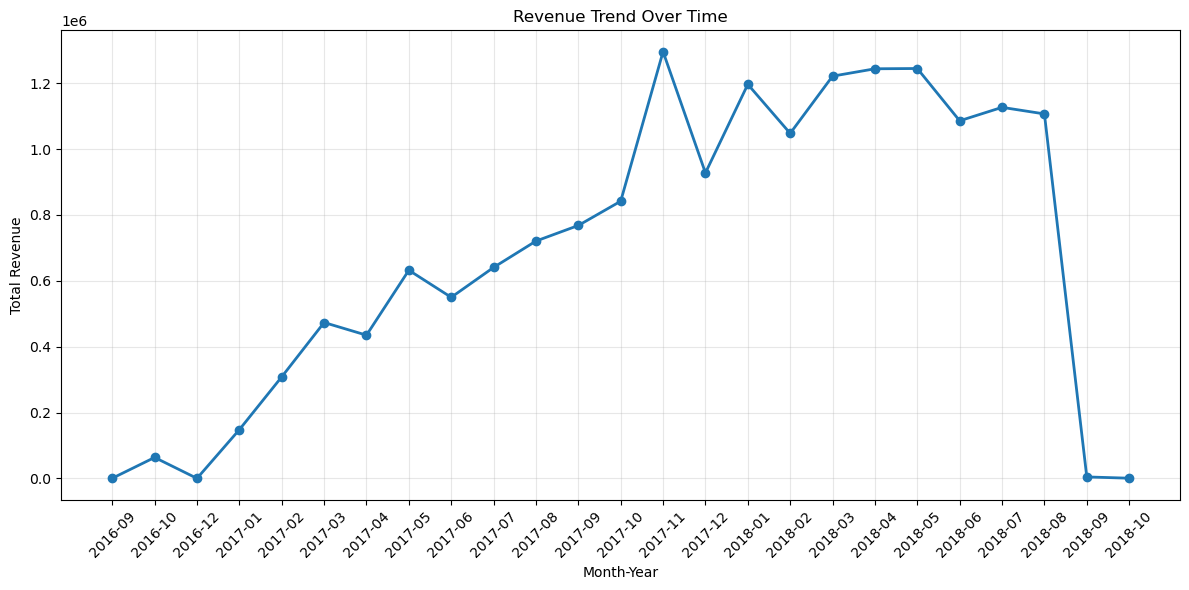

In [158]:
plt.figure(figsize=(12, 6))
plt.plot(revenue_trend.index, revenue_trend['total_revenue'], marker='o', linewidth=2, markersize=6)
plt.title('Revenue Trend Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [159]:
filtered_revenue_trend = revenue_trend[~(
    revenue_trend.index.str.startswith('2016') |
    revenue_trend.index.isin(['2018-09', '2018-10'])
)]

filtered_revenue_trend

,total_revenue
month_year,
2017-01,148005.22
2017-02,308318.90
2017-03,473338.98
2017-04,434880.80
2017-05,632097.21
2017-06,549815.67
2017-07,640615.64
2017-08,720657.52
2017-09,768020.72


In [160]:

filtered_revenue_trend['lag_revenue'] = filtered_revenue_trend['total_revenue'].shift(1)
filtered_revenue_trend['delta'] = filtered_revenue_trend['total_revenue'] - filtered_revenue_trend['lag_revenue']
filtered_revenue_trend['pct_change'] = filtered_revenue_trend['delta'] / filtered_revenue_trend['lag_revenue']
filtered_revenue_trend['rolling_avg'] = filtered_revenue_trend['total_revenue'].rolling(window=3).mean()

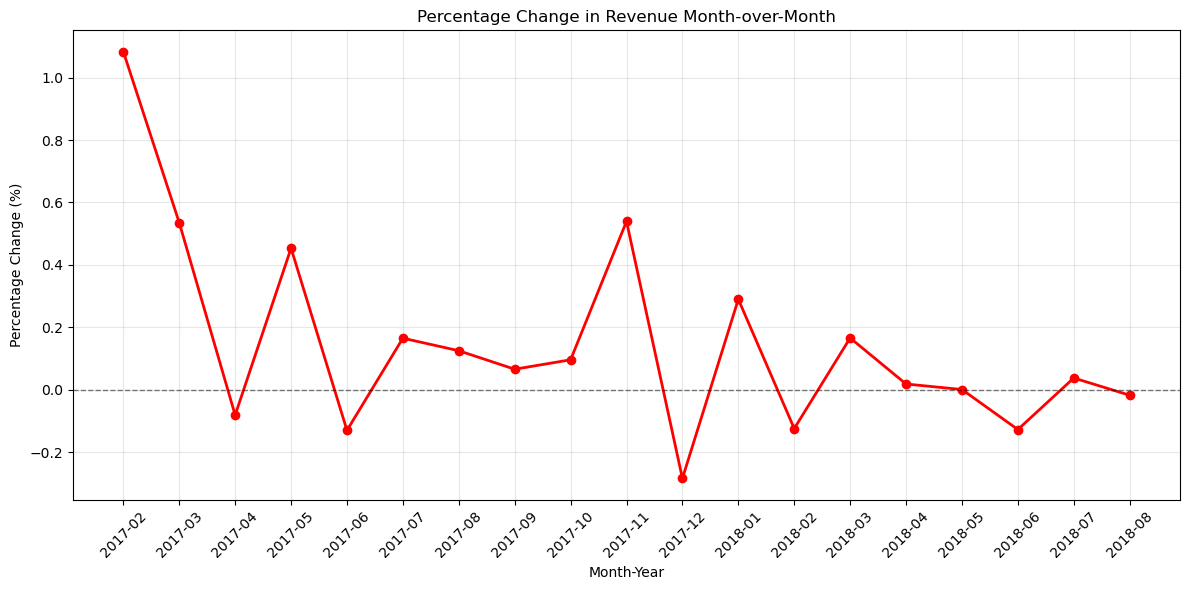

In [161]:
plt.figure(figsize=(12, 6))
plt.plot(filtered_revenue_trend.index, filtered_revenue_trend['pct_change'], marker='o', linewidth=2, markersize=6, color='red')
plt.title('Percentage Change in Revenue Month-over-Month')
plt.xlabel('Month-Year')
plt.ylabel('Percentage Change (%)')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

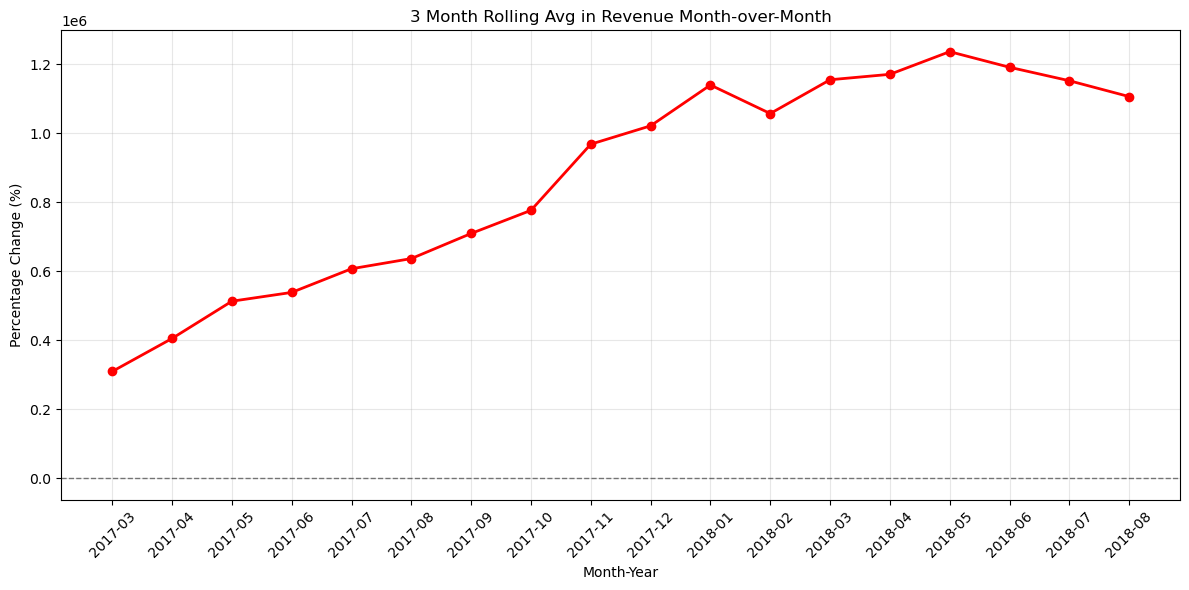

In [162]:
plt.figure(figsize=(12, 6))
plt.plot(filtered_revenue_trend.index, filtered_revenue_trend['rolling_avg'], marker='o', linewidth=2, markersize=6, color='red')
plt.title('3 Month Rolling Avg in Revenue Month-over-Month')
plt.xlabel('Month-Year')
plt.ylabel('Percentage Change (%)')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [163]:
revenue_trend.head() 

,total_revenue
month_year,
2016-09,388.47
2016-10,63595.03
2016-12,19.62
2017-01,148005.22
2017-02,308318.90


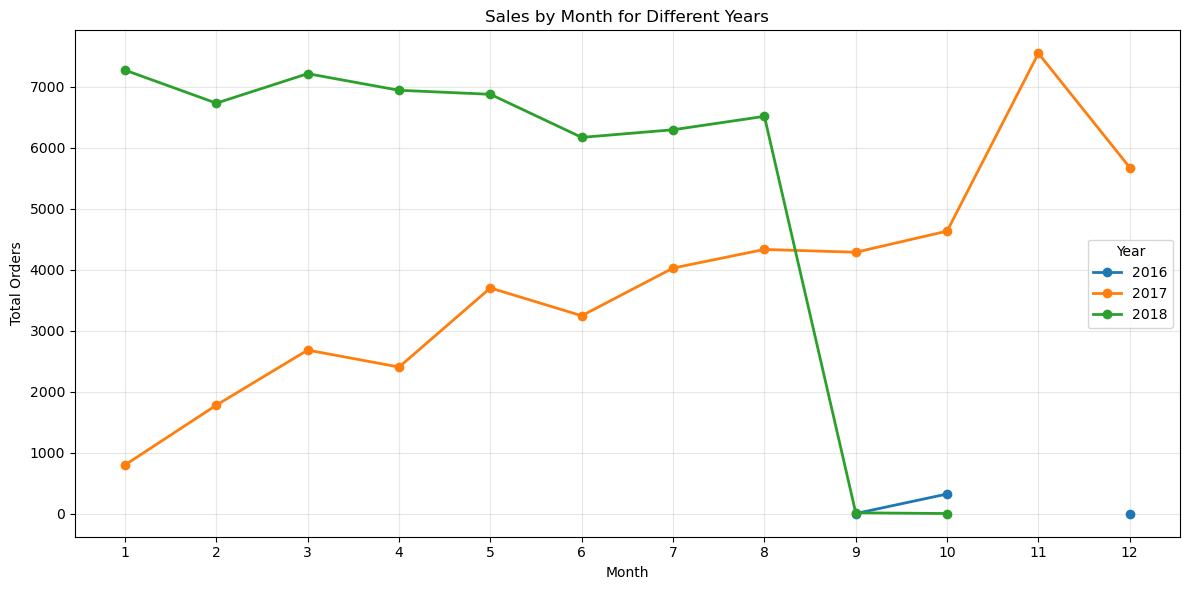

In [164]:
# Prepare data for sales by month for different years
sales_by_month_year = combined.groupby(['year_of_purchase', 'month_of_purchase']).agg({'order_id': 'nunique'}).reset_index().rename(columns={'order_id': 'total_orders'})

# Create pivot table with months as rows and years as columns
pivot_sales = sales_by_month_year.pivot(index='month_of_purchase', columns='year_of_purchase', values='total_orders')

# Create line plot
plt.figure(figsize=(12, 6))
for year in pivot_sales.columns:
    plt.plot(pivot_sales.index, pivot_sales[year], marker='o', label=str(year), linewidth=2)

plt.title('Sales by Month for Different Years')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

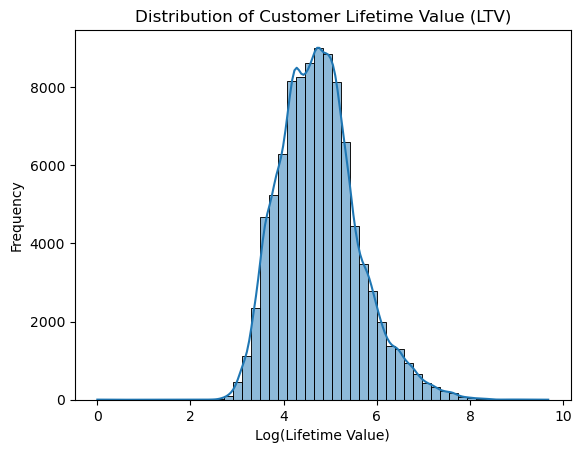

In [165]:
sns.histplot(np.log(customer_facts['ltv'] + 1), bins=50, kde=True)
plt.title('Distribution of Customer Lifetime Value (LTV)')
plt.xlabel('Log(Lifetime Value)')
plt.ylabel('Frequency')
plt.show()

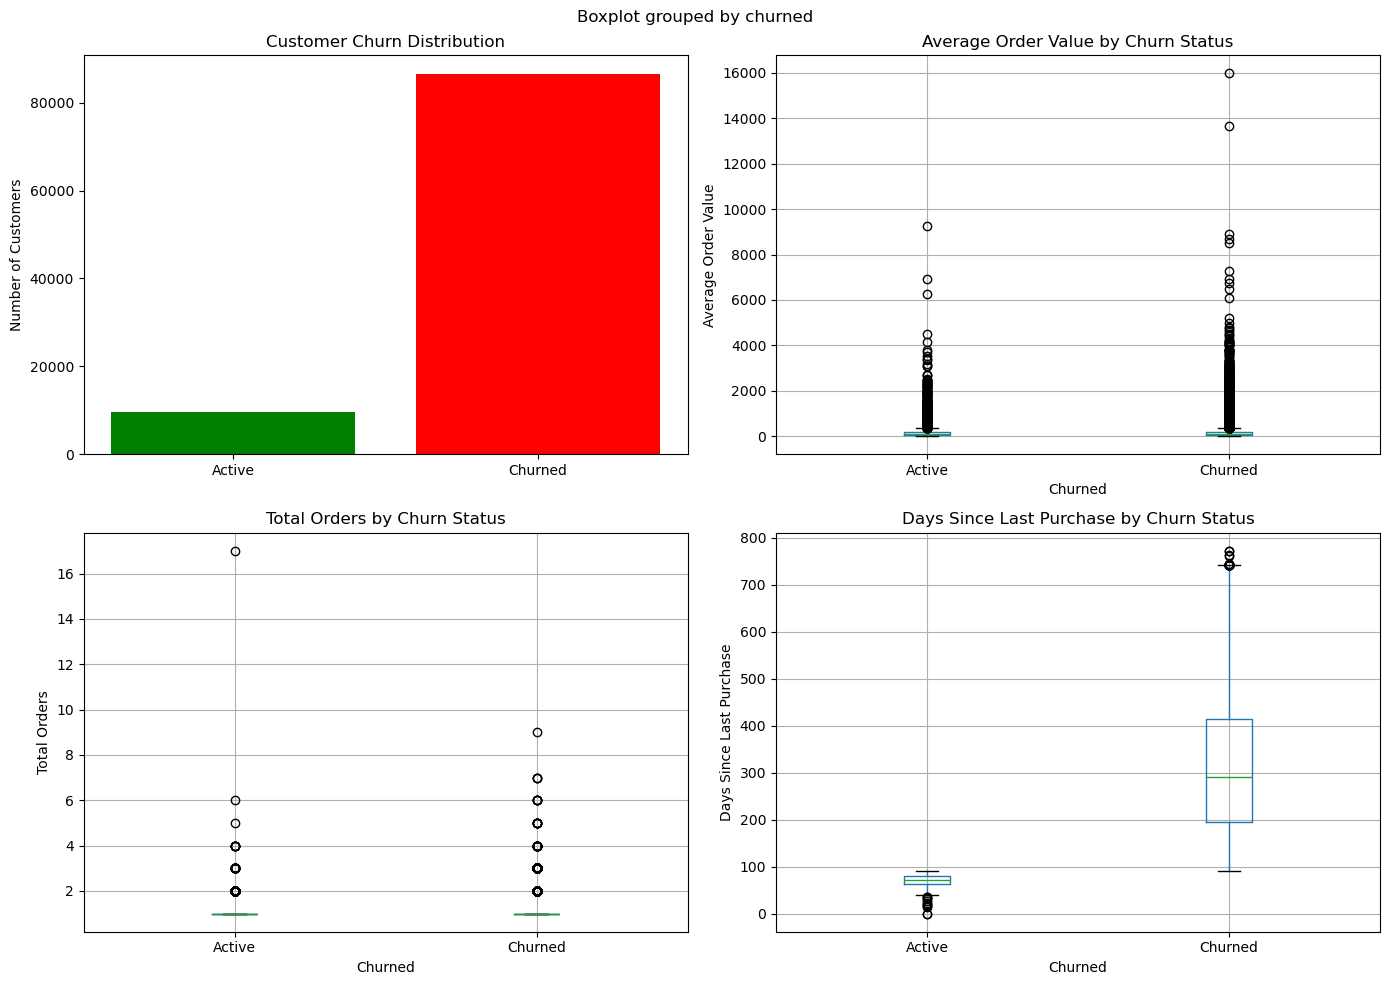

In [166]:
# Create visualizations for customer churn analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn vs Non-Churn Distribution
churn_counts = customer_facts['churned'].value_counts()
axes[0, 0].bar(['Active', 'Churned'], [churn_counts[False], churn_counts[True]], color=['green', 'red'])
axes[0, 0].set_title('Customer Churn Distribution')
axes[0, 0].set_ylabel('Number of Customers')

# 2. Average Order Value by Churn Status
customer_facts.boxplot(column='avg_order_value', by='churned', ax=axes[0, 1])
axes[0, 1].set_title('Average Order Value by Churn Status')
axes[0, 1].set_xlabel('Churned')
axes[0, 1].set_ylabel('Average Order Value')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Active', 'Churned'])

# 3. Total Orders by Churn Status
customer_facts.boxplot(column='total_orders', by='churned', ax=axes[1, 0])
axes[1, 0].set_title('Total Orders by Churn Status')
axes[1, 0].set_xlabel('Churned')
axes[1, 0].set_ylabel('Total Orders')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Active', 'Churned'])

# 4. Days Since Last Purchase by Churn Status
customer_facts.boxplot(column='day_since_last_purchase', by='churned', ax=axes[1, 1])
axes[1, 1].set_title('Days Since Last Purchase by Churn Status')
axes[1, 1].set_xlabel('Churned')
axes[1, 1].set_ylabel('Days Since Last Purchase')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Active', 'Churned'])

plt.tight_layout()
plt.show()

         count       mean     median       std
churned                                       
False     9461   8.012619   7.092014  4.868143
True     83903  13.082015  10.870370  9.806410


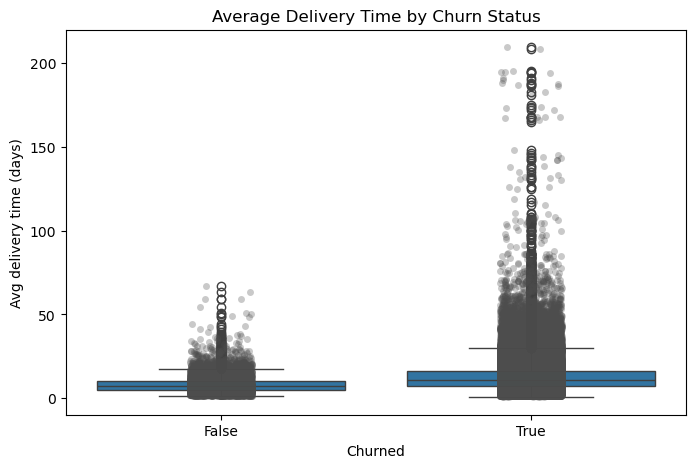

mannwhitneyu stat=242659440.000, p-value=0.000e+00
Pearson correlation (avg_delivery_time vs churn): 0.16022444588907753


In [167]:
from scipy.stats import mannwhitneyu

# aggregate delivery metrics per customer and merge with customer_facts
delivery_stats = combined.groupby('customer_unique_id').agg(
    avg_delivery_time=('time_taken_to_deliver', 'mean'),
    median_delivery_time=('time_taken_to_deliver', 'median'),
    on_time_rate=('on_time_delivery', 'mean'),
    orders_count=('order_id', 'nunique')
).reset_index()

cust_delivery = customer_facts.merge(delivery_stats, on='customer_unique_id', how='left')

# prepare data for analysis
df = cust_delivery.dropna(subset=['avg_delivery_time'])

# summary statistics by churn
print(df.groupby('churned')['avg_delivery_time'].agg(['count', 'mean', 'median', 'std']))

# boxplot + stripplot to visualize relationship
plt.figure(figsize=(8, 5))
sns.boxplot(x='churned', y='avg_delivery_time', data=df)
sns.stripplot(x='churned', y='avg_delivery_time', data=df, color='0.3', alpha=0.3, jitter=True)
plt.xlabel('Churned')
plt.ylabel('Avg delivery time (days)')
plt.title('Average Delivery Time by Churn Status')
plt.show()

# statistical test (Mann-Whitney U) and correlation
a = df.loc[df['churned'] == False, 'avg_delivery_time']
b = df.loc[df['churned'] == True, 'avg_delivery_time']
stat, p = mannwhitneyu(a, b, alternative='two-sided')
print(f"mannwhitneyu stat={stat:.3f}, p-value={p:.3e}")
print('Pearson correlation (avg_delivery_time vs churn):', df['avg_delivery_time'].corr(df['churned'].astype(int)))

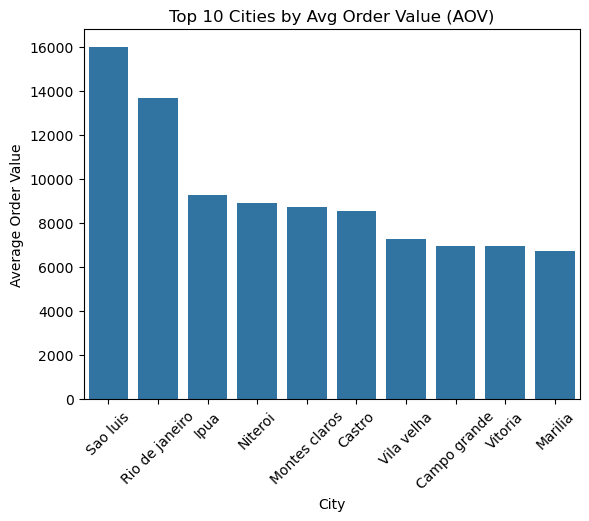

In [168]:
sns.barplot(x= 'city', y='avg_order_value', data=customer_facts.sort_values(by='avg_order_value', ascending=False).head(10))
plt.title('Top 10 Cities by Avg Order Value (AOV)')
plt.xlabel('City')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.show()

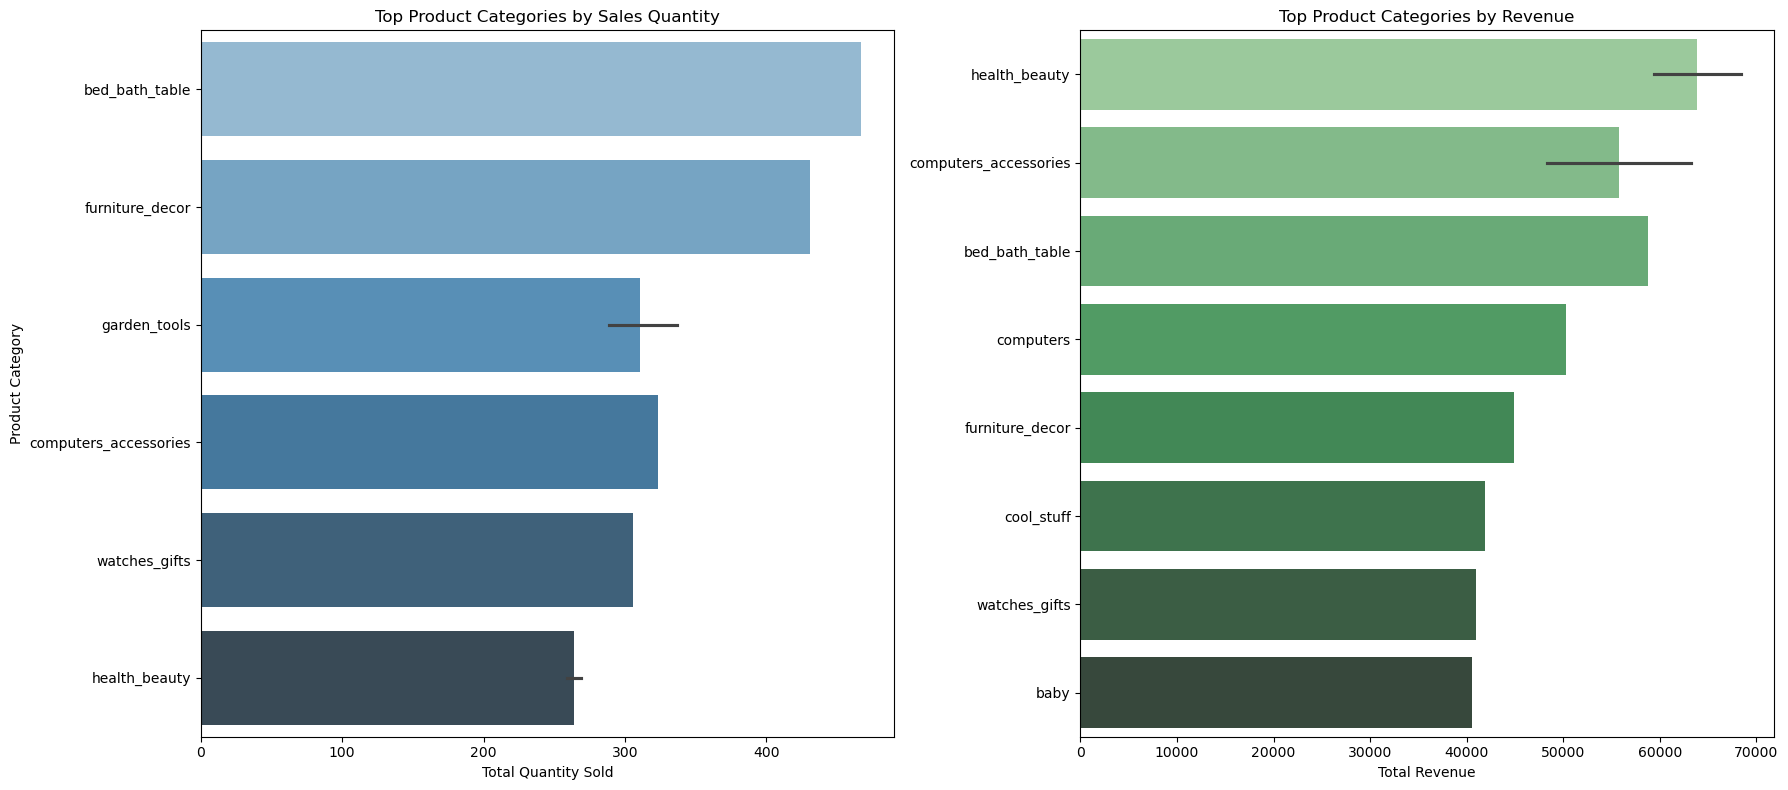

In [169]:
top_sales = product_facts.sort_values('total_orders', ascending=False).head(10)
top_revenue = product_facts.sort_values('total_revenue', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    x='total_orders',
    y='category_name',
    data=top_sales,
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Top Product Categories by Sales Quantity')
axes[0].set_xlabel('Total Quantity Sold')
axes[0].set_ylabel('Product Category')

sns.barplot(
    x='total_revenue',
    y='category_name',
    data=top_revenue,
    ax=axes[1],
    palette='Greens_d'
)
axes[1].set_title('Top Product Categories by Revenue')
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

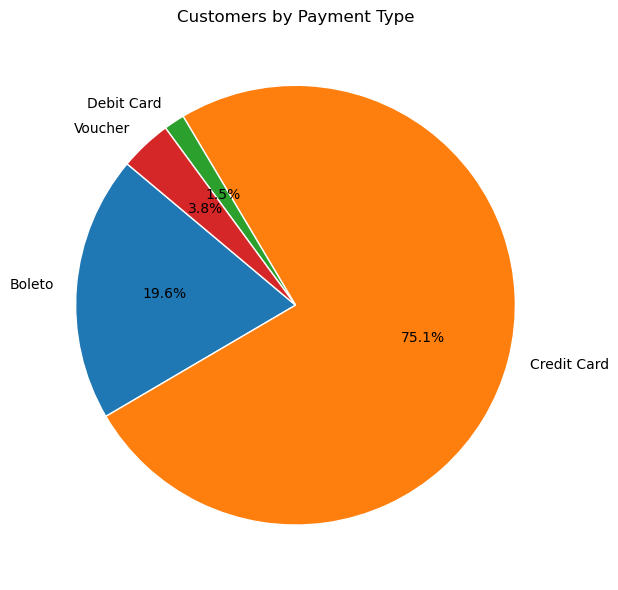

In [170]:
plt.figure(figsize=(8, 6))
plt.figure(figsize=(8, 6))
plt.pie(payment_facts['total_customers'].tolist(),
    labels=payment_facts['payment_type'].astype(str).tolist(),
    autopct='%.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'})
plt.title('Customers by Payment Type')
plt.tight_layout()
plt.show()

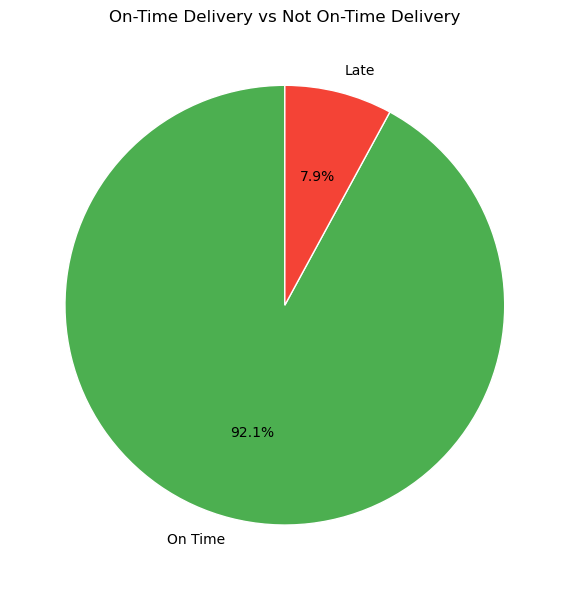

In [171]:
on_time_counts = combined[~combined['delivered_customer_tmsp'].isnull()]['on_time_delivery'].value_counts()
values = [on_time_counts.get(True, 0), on_time_counts.get(False, 0)]
labels = ['On Time', 'Late']

plt.figure(figsize=(6, 6))
plt.pie(
    values,
    labels=labels,
    autopct='%.1f%%',
    startangle=90,
    colors=['#4CAF50', '#F44336'],
    wedgeprops={'edgecolor': 'white'}
)
plt.title('On-Time Delivery vs Not On-Time Delivery')
plt.tight_layout()
plt.show()

In [172]:
combined.groupby('on_time_delivery').agg({'review_score': 'mean'}).reset_index().rename(columns={'review_score': 'avg_review_score'})

,on_time_delivery,avg_review_score
0,False,2.339540
1,True,4.255673


review_score        1.0   2.0    3.0    4.0    5.0
on_time_delivery                                  
False             52.82  7.96  10.18  10.51  18.52
True               7.40  2.86   8.10  20.07  61.57


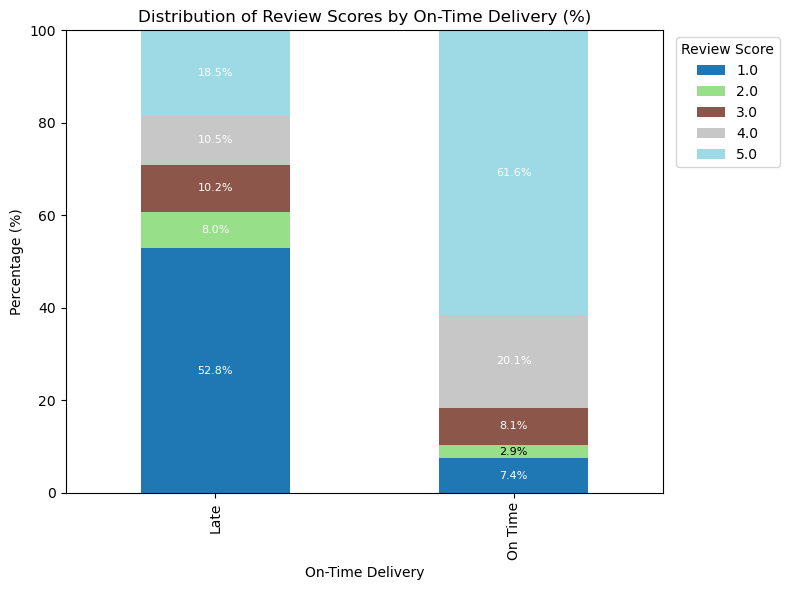

In [173]:
pivot_table = combined.groupby(['on_time_delivery', 'review_score']).size().unstack(fill_value=0)
pivot_table = pivot_table.reindex(columns=sorted(pivot_table.columns))

pivot_pct = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100
print(pivot_pct.round(2))

ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(8,6), colormap='tab20')
ax.set_title('Distribution of Review Scores by On-Time Delivery (%)')
ax.set_xlabel('On-Time Delivery')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.set_xticklabels(['Late' if not x else 'On Time' for x in pivot_pct.index])

# annotate percentages on bars
for i, (_, row) in enumerate(pivot_pct.iterrows()):
    cum = 0
    for val in row:
        if val > 0:
            ax.text(i, cum + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=8,
                    color='white' if val > 5 else 'black')
        cum += val

ax.legend(title='Review Score', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

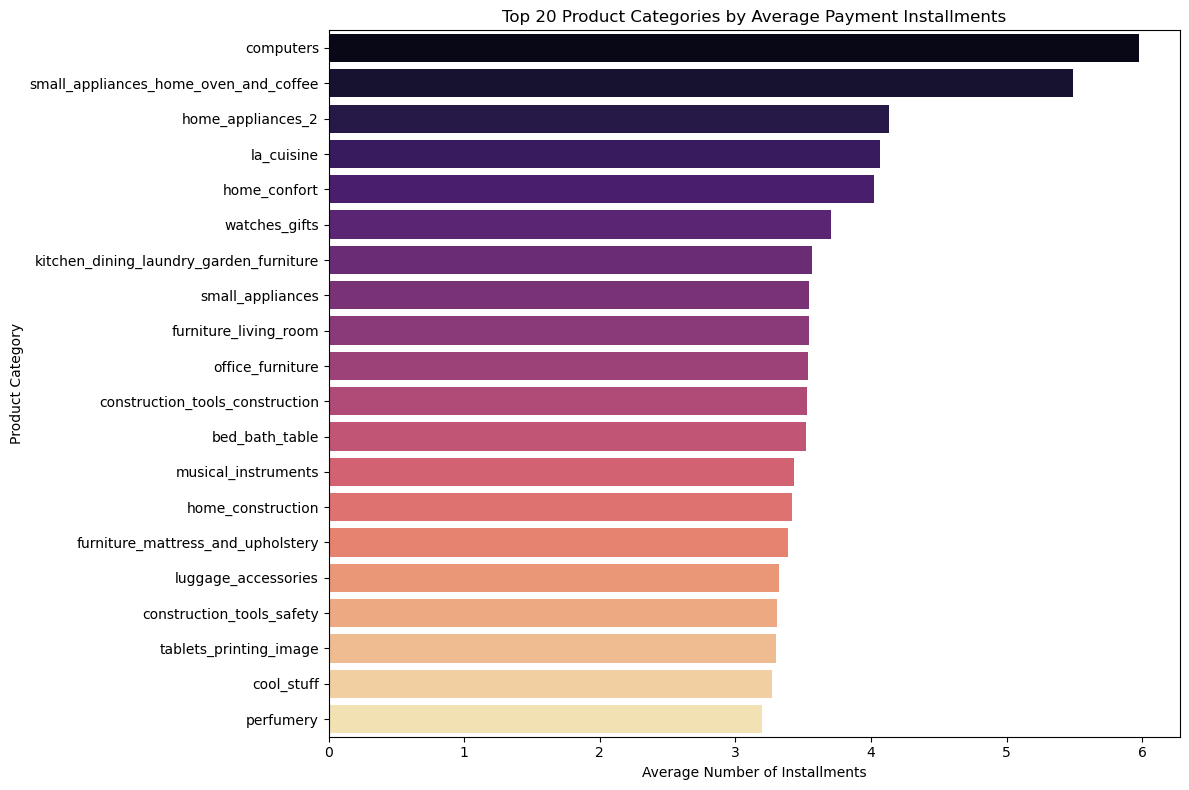

In [174]:
payment_installments_by_category = combined.groupby('category_name_english').agg(
    avg_installments=('payment_installments', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

top_categories_installments = (
    payment_installments_by_category[payment_installments_by_category['total_orders'] >= 5]
    .sort_values('avg_installments', ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_categories_installments,
    x='avg_installments',
    y='category_name_english',
    palette='magma'
)
plt.title('Top 20 Product Categories by Average Payment Installments')
plt.xlabel('Average Number of Installments')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

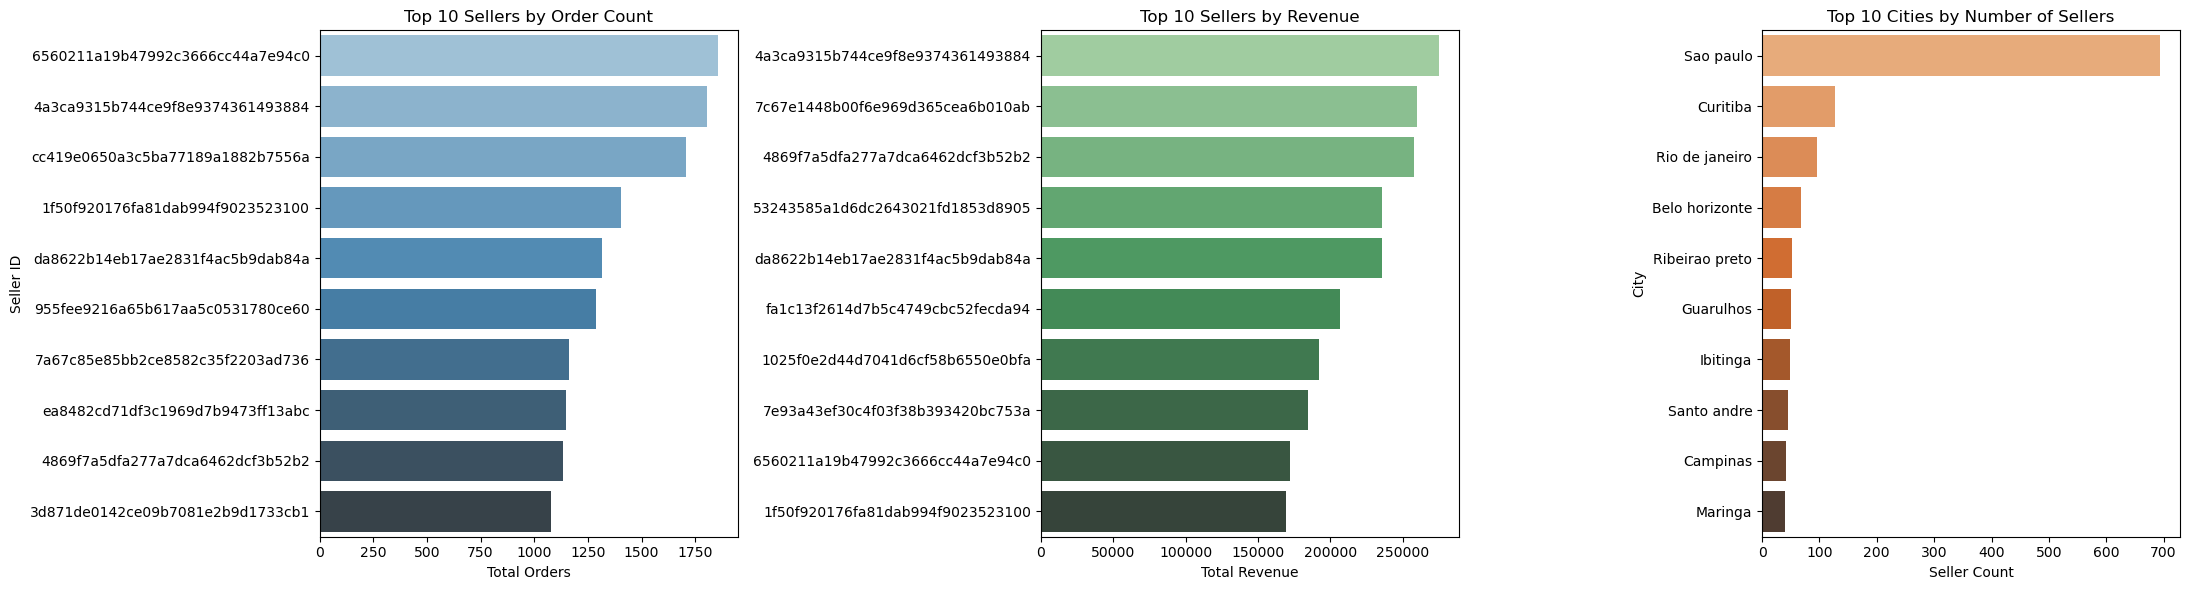

In [175]:
top_sellers_orders = seller_facts.nlargest(10, 'total_orders')
top_sellers_revenue = seller_facts.nlargest(10, 'total_revenue')
top_city_counts = seller_facts['city'].value_counts().head(10).reset_index()
top_city_counts.columns = ['city', 'seller_count']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    x='total_orders',
    y='seller_id',
    data=top_sellers_orders,
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Top 10 Sellers by Order Count')
axes[0].set_xlabel('Total Orders')
axes[0].set_ylabel('Seller ID')

sns.barplot(
    x='total_revenue',
    y='seller_id',
    data=top_sellers_revenue,
    ax=axes[1],
    palette='Greens_d'
)
axes[1].set_title('Top 10 Sellers by Revenue')
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('')

sns.barplot(
    x='seller_count',
    y='city',
    data=top_city_counts,
    ax=axes[2],
    palette='Oranges_d'
)
axes[2].set_title('Top 10 Cities by Number of Sellers')
axes[2].set_xlabel('Seller Count')
axes[2].set_ylabel('City')

plt.tight_layout()
plt.show()